In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # we will use it for visualization
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.optimize import milp
from scipy import optimize
from scipy.sparse.csgraph import shortest_path

At each round $t \in [T]$:

1. The advertiser sets a bid $b_i$ for each campaign $i \in \{1, \dots, N\}$.
2. The other bidders select a competing bid $m_i$ for each campaign $i \in \{1, \dots, N\}$.
3. The advertiser wins all the auctions such that $b_i \geq m_i$.
4. Observe **Feedback**: set of won auctions.
5. For each won auction, the advertiser gets utility

$$
v_i - b_i,
$$

and pays cost $b_i$.

Lets consider again that each campaign behaves like a uniform distribution. So thereore the maximum bid behaves like a beta. For this lets just choose differetn number of advertisers for each campaing

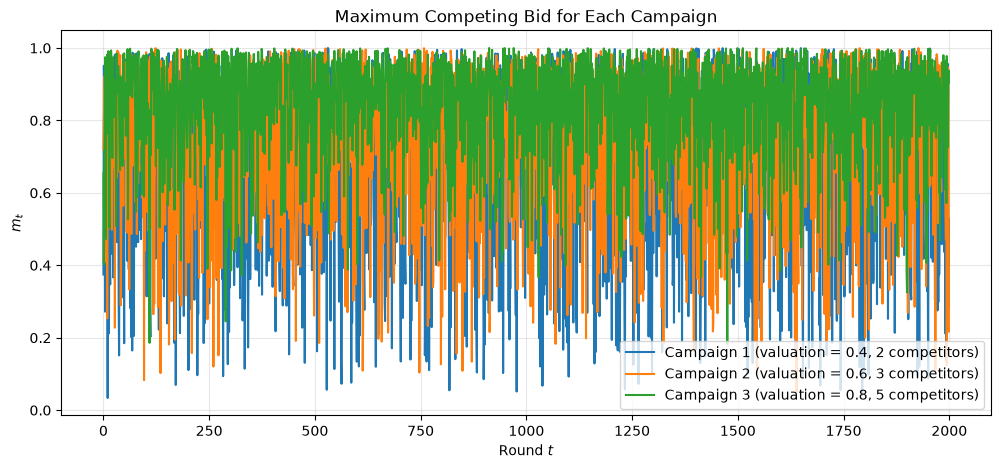

Campaign valuations: [0.4 0.6 0.8]
Number of competitors: [2, 3, 5]
Shape of m_t: (3, 2000)
Budget per round: 0.15


In [22]:
# Reproducibility
np.random.seed(42)

# Problem parameters
n_campaigns = 3
n_users = 2000  # Number of rounds
B = 300
rho = B / n_users

# Different valuation for each campaign
my_valuations = np.array([0.4, 0.6, 0.8])

# Different number of competitors for each campaign
n_competitors = [2, 3, 5]

# Generate uniformly distributed bids for each campaign
other_bids = [
    np.random.uniform(
        0,
        1,
        size=(n_competitors[campaign], n_users)
    )
    for campaign in range(n_campaigns)
]

# Maximum competing bid for each campaign and round
m_t = np.array([
    campaign_bids.max(axis=0)
    for campaign_bids in other_bids
])

# Plot the maximum competing bid for each campaign
plt.figure(figsize=(12, 5))

for campaign in range(n_campaigns):
    plt.plot(
        m_t[campaign],
        label=(
            f"Campaign {campaign + 1} "
            f"(valuation = {my_valuations[campaign]}, "
            f"{n_competitors[campaign]} competitors)"
        )
    )

plt.title("Maximum Competing Bid for Each Campaign")
plt.xlabel("Round $t$")
plt.ylabel("$m_t$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Campaign valuations:", my_valuations)
print("Number of competitors:", n_competitors)
print("Shape of m_t:", m_t.shape)
print("Budget per round:", rho)

Possible bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


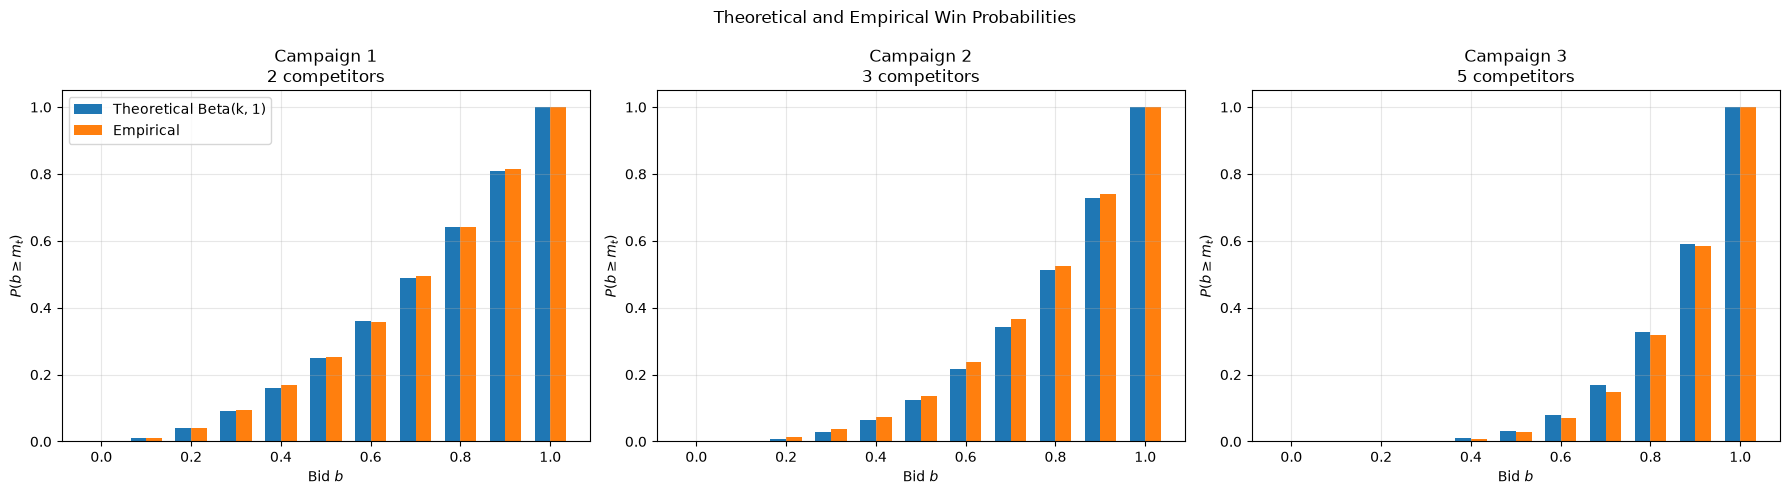

In [23]:
from scipy import stats

available_bids = np.linspace(0, 1, 11)

print(f"Possible bids space: {available_bids}")

plt.figure(figsize=(18, 5))

for campaign in range(n_campaigns):
    k = n_competitors[campaign]

    # Theoretical probability:
    # maximum of k Uniform(0, 1) variables ~ Beta(k, 1)
    win_probabilities = stats.beta.cdf(
        available_bids,
        k,
        1
    )

    # Empirical probability of winning for each possible bid
    emp_win_probabilities = np.array([
        np.mean(available_bid >= m_t[campaign])
        for available_bid in available_bids
    ])

    plt.subplot(1, n_campaigns, campaign + 1)

    width = 0.035

    plt.bar(
        available_bids - width / 2,
        win_probabilities,
        width=width,
        label="Theoretical Beta(k, 1)"
    )

    plt.bar(
        available_bids + width / 2,
        emp_win_probabilities,
        width=width,
        label="Empirical"
    )

    plt.title(
        f"Campaign {campaign + 1}\n"
        f"{k} competitors"
    )
    plt.xlabel("Bid $b$")
    plt.ylabel("$P(b \\geq m_t)$")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)

    if campaign == 0:
        plt.legend()

plt.suptitle("Theoretical and Empirical Win Probabilities")
plt.tight_layout()
plt.show()

## Multiple Campaigns Witouth Restrictions

Now we have $N$ campaigns,
each with valuation $v_i$, sharing the same discrete bid set $\mathcal{B}$
and a single, shared budget $B$. Let $\mathbb{P}_i(b) = \mathbb{P}(b \geq m_i)$
be campaign $i$'s win probability for bid $b$ (the counterpart of
$\mathbb{P}(b \geq m_t)$, now indexed by campaign).

**Decision variable.** Instead of one distribution $\gamma \in \Delta(\mathcal{B})$,
you now need one distribution per campaign, $\gamma_i \in \Delta(\mathcal{B})$
for each $i \in \{1,\dots,N\}$, $\gamma_i(b)$ is the probability of bidding
$b$ on campaign $i$.

With this in mind, now the **Per-round expected reward and cost** become

$$
f(\gamma) = \sum_{i=1}^{N} \sum_{b \in \mathcal{B}} \gamma_i(b)\,(v_i - b)\,\mathbb{P}_i(b), \qquad c(\gamma) = \sum_{i=1}^{N} \sum_{b \in \mathcal{B}} \gamma_i(b)\, b\, \mathbb{P}_i(b)
$$

The clairvoyant LP (the counterpart of Requirement 1's LP, now with $N$
simplices tied together by the one shared budget constraint):

$$
\text{maximize}_{\gamma_1,\dots,\gamma_N \in \Delta(\mathcal{B})} \;\; \sum_{i=1}^{N}\sum_{b \in \mathcal{B}} \gamma_i(b)\,(v_i-b)\,\mathbb{P}_i(b)
$$

$$
\text{s.t.} \;\; \sum_{i=1}^{N}\sum_{b \in \mathcal{B}} \gamma_i(b)\, b\, \mathbb{P}_i(b) \leq \rho, \qquad \rho = \frac{B}{T}
$$

$$
\sum_{b \in \mathcal{B}} \gamma_i(b) = 1 \;\; \forall i \in \{1,\dots,N\}, \qquad 0 \leq \gamma_i(b) \leq 1 \;\; \forall i, b
$$

This is still a Linear Programming Problem

In [24]:
## Multiple Campaigns Without Restrictions

# Each campaign has its own valuation v_i and win probability P_i(b).
# All campaigns share the same bid set and budget constraint.

from scipy import optimize

# Discrete set of possible bids
available_bids = np.linspace(0, 1, 11)
n_bids = len(available_bids)

# Theoretical win probabilities for each campaign
# P_i(b) = b^(k_i), because max of k_i Uniform(0, 1) variables
win_probabilities = np.array([
    available_bids ** n_competitors[campaign]
    for campaign in range(n_campaigns)
])

print("Possible bids:", available_bids)
print("Win probability matrix shape:", win_probabilities.shape)


def compute_clairvoyant_multiple_campaigns(
    available_bids,
    my_valuations,
    rho,
    win_probabilities
):
    n_campaigns = len(my_valuations)
    n_bids = len(available_bids)

    # Flatten variables:
    # gamma[0, 0], ..., gamma[0, K-1],
    # gamma[1, 0], ..., gamma[N-1, K-1]

    # Objective coefficients
    reward_coefficients = np.array([
        (my_valuations[campaign] - available_bids)
        * win_probabilities[campaign]
        for campaign in range(n_campaigns)
    ])

    objective = -reward_coefficients.flatten()

    # Shared budget constraint
    cost_coefficients = np.array([
        available_bids * win_probabilities[campaign]
        for campaign in range(n_campaigns)
    ])

    A_ub = [cost_coefficients.flatten()]
    b_ub = [rho]

    # One probability distribution per campaign:
    # sum_b gamma_i(b) = 1
    A_eq = np.zeros((n_campaigns, n_campaigns * n_bids))

    for campaign in range(n_campaigns):
        start = campaign * n_bids
        end = (campaign + 1) * n_bids
        A_eq[campaign, start:end] = 1

    b_eq = np.ones(n_campaigns)

    # Solve the clairvoyant linear program
    result = optimize.linprog(
        objective,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=(0, 1),
        method="highs"
    )

    if not result.success:
        raise ValueError(result.message)

    # Reshape the solution into one distribution per campaign
    gamma = result.x.reshape(n_campaigns, n_bids)

    expected_reward = -result.fun
    expected_cost = np.sum(
        gamma * cost_coefficients
    )

    return gamma, expected_reward, expected_cost


# Compute the optimal bidding distributions
gamma, expected_reward, expected_cost = (
    compute_clairvoyant_multiple_campaigns(
        available_bids,
        my_valuations,
        rho,
        win_probabilities
    )
)

# Display the solution
for campaign in range(n_campaigns):
    print(f"\nCampaign {campaign + 1}")
    print(f"Valuation: {my_valuations[campaign]}")
    print(f"Competitors: {n_competitors[campaign]}")
    print("Optimal bid distribution:")

    for bid_index, bid in enumerate(available_bids):
        if gamma[campaign, bid_index] > 1e-6:
            print(
                f"  Bid {bid:.1f}: "
                f"probability {gamma[campaign, bid_index]:.4f}"
            )

print("\nTotal expected reward:", expected_reward)
print("Total expected cost:", expected_cost)
print("Available budget per round:", rho)

Possible bids: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Win probability matrix shape: (3, 11)

Campaign 1
Valuation: 0.4
Competitors: 2
Optimal bid distribution:
  Bid 0.3: probability 1.0000

Campaign 2
Valuation: 0.6
Competitors: 3
Optimal bid distribution:
  Bid 0.4: probability 1.0000

Campaign 3
Valuation: 0.8
Competitors: 5
Optimal bid distribution:
  Bid 0.6: probability 0.2852
  Bid 0.7: probability 0.7148

Total expected reward: 0.03824904224360148
Total expected cost: 0.15
Available budget per round: 0.15


## Multiple Campaings With Restrictions


In the previous problem each campaign had its own independent simplex $\gamma_i \in \Delta(\mathcal{B})$,
coupled only through the shared budget. That was valid because nothing stopped us from bidding on all $N$ campaigns simultaneously every round. With the conflict graph $G=(V,E)$ (nodes = campaigns, edges = mutually-exclusive pairs), the set of campaigns actually active in a round must be an independent set of $G$. So which campaigns we can bid on jointly is now itself a combinatorial choice, and per-campaign distributions can no longer be optimized independently: activating campaign $i$ this round forecloses any neighbor of $i$ in $G$.

**What is the Fix?** Define a feasible set of campaings which we can choose using the constraing imposed by the graph, lets name this set

$$
\mathcal{A} = \Big\{ (S, b_S) \;:\; S \in \mathcal{I}(G), \; b_S = (b_i)_{i \in S} \in \mathcal{B}^{|S|} \Big\}
$$

Each element of $\mathcal{A}$ is a pair $(S, b_S)$:

- $S$ is which campaigns are decide to bid on the round, a subset of $\{1, \dots, N\}$.
- $b_S = (b_i)_{i \in S}$ is the bid we place for each campaign in that subset, one bid value per campaign in $S$.

where $\mathcal{I}(G)$ is the set of independent sets of the conflict graph $G$, i.e. a super-arm $a = (S, b_S)$ picks a conflict-free subset of campaigns $S$ and a bid for each campaign in it. With this the update the **per-round expected reward and cost** become

$$
f(\gamma) = \sum_{(S,b_S) \in \mathcal{A}} \gamma(S,b_S) \sum_{i \in S} (v_i - b_i)\,\mathbb{P}_i(b_i), \qquad c(\gamma) = \sum_{(S,b_S) \in \mathcal{A}} \gamma(S,b_S) \sum_{i \in S} b_i\,\mathbb{P}_i(b_i)
$$

The clairvoyant LP (the counterpart of Requirement 1's LP and the
unconstrained multi-campaign LP, now with **one** simplex over super-arms
instead of $N$ separate simplices):

$$
\text{maximize}_{\gamma \in \Delta(\mathcal{A})} \;\; f(\gamma)
$$

$$
\text{s.t.} \;\; c(\gamma) \leq \rho, \qquad \rho = \frac{B}{T}
$$

$$
\sum_{(S,b_S) \in \mathcal{A}} \gamma(S,b_S) = 1, \qquad 0 \leq \gamma(S,b_S) \leq 1 \;\; \forall (S,b_S) \in \mathcal{A}
$$

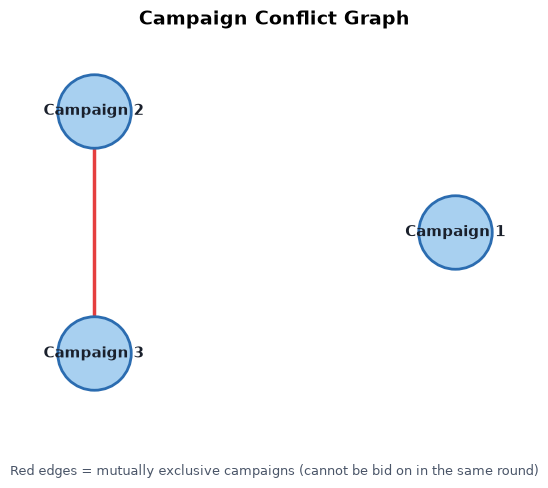

In [25]:
## Multiple Campaigns With Restrictions

from itertools import combinations, product
from scipy import optimize

# Campaigns are represented by 0, 1, and 2
campaigns = list(range(n_campaigns))

# Conflict graph:
# Campaign 1 conflicts with Campaign 2
# Campaign 2 conflicts with Campaign 3
# Campaigns 1 and 3 can be active together
conflict_edges = [
    (1, 2)
]

# Create the conflict graph
conflict_graph = nx.Graph()
conflict_graph.add_nodes_from(campaigns)
conflict_graph.add_edges_from(conflict_edges)

labels = {campaign: f"Campaign {campaign + 1}" for campaign in campaigns}

fig, ax = plt.subplots(figsize=(6, 5))

pos = nx.circular_layout(conflict_graph)

nx.draw_networkx_nodes(
    conflict_graph, pos, ax=ax,
    node_color="#a8d0f0",
    edgecolors="#2b6cb0",
    linewidths=2,
    node_size=2800
)

nx.draw_networkx_edges(
    conflict_graph, pos, ax=ax,
    edgelist=conflict_edges,
    edge_color="#e53e3e",
    width=2.5,
    style="solid"
)

nx.draw_networkx_labels(
    conflict_graph, pos, labels=labels, ax=ax,
    font_size=11, font_weight="bold", font_color="#1a202c"
)

ax.set_title("Campaign Conflict Graph", fontsize=14, fontweight="bold", pad=15)
ax.text(
    0.5, -0.15,
    "Red edges = mutually exclusive campaigns (cannot be bid on in the same round)",
    transform=ax.transAxes, ha="center", fontsize=9, color="#4a5568"
)
ax.set_axis_off()
ax.margins(0.2)

plt.tight_layout()
plt.show()


In [26]:
from itertools import combinations, product
from collections import namedtuple
from scipy import optimize


ClairvoyantResult = namedtuple(
    "ClairvoyantResult",
    ["gamma", "super_arms", "super_arm_rewards", "super_arm_costs",
     "expected_reward", "expected_cost"]
)


def enumerate_independent_sets(n_campaigns, conflict_edges):
    """All subsets of {0, ..., n_campaigns-1} with no conflicting pair."""
    conflicts = set(conflict_edges)

    def is_independent(subset):
        subset = set(subset)
        return not any({i, j} <= subset for i, j in conflicts)

    return [
        subset
        for size in range(n_campaigns + 1)
        for subset in combinations(range(n_campaigns), size)
        if is_independent(subset)
    ]


def build_super_arms(independent_sets, available_bids):
    """One super-arm per (feasible subset, bid combination)."""
    super_arms = []
    for subset in independent_sets:
        if not subset:
            super_arms.append((subset, ()))
        else:
            super_arms.extend(
                (subset, bids)
                for bids in product(available_bids, repeat=len(subset))
            )
    return super_arms


def evaluate_super_arms(super_arms, my_valuations, win_probabilities, bid_to_index):
    """Expected reward/cost of every super-arm, reusing win_probabilities."""
    rewards = np.zeros(len(super_arms))
    costs = np.zeros(len(super_arms))

    for k, (subset, bids) in enumerate(super_arms):
        for campaign, bid in zip(subset, bids):
            p = win_probabilities[campaign, bid_to_index[bid]]
            rewards[k] += (my_valuations[campaign] - bid) * p
            costs[k] += bid * p

    return rewards, costs


def compute_clairvoyant_with_restrictions(
    available_bids, my_valuations, rho, win_probabilities, conflict_edges
):
    n_campaigns = len(my_valuations)
    bid_to_index = {b: i for i, b in enumerate(available_bids)}

    independent_sets = enumerate_independent_sets(n_campaigns, conflict_edges)
    super_arms = build_super_arms(independent_sets, available_bids)
    super_arm_rewards, super_arm_costs = evaluate_super_arms(
        super_arms, my_valuations, win_probabilities, bid_to_index
    )

    result = optimize.linprog(
        -super_arm_rewards,
        A_ub=[super_arm_costs], b_ub=[rho],
        A_eq=[np.ones(len(super_arms))], b_eq=[1],
        bounds=(0, 1), method="highs"
    )
    if not result.success:
        raise ValueError(result.message)

    gamma = result.x
    return ClairvoyantResult(
        gamma, super_arms, super_arm_rewards, super_arm_costs,
        expected_reward=-result.fun,
        expected_cost=gamma @ super_arm_costs,
    )


def print_clairvoyant_solution(result, rho):
    print(f"Number of super-arms: {len(result.super_arms)}\n")
    for (subset, bids), probability, reward, cost in zip(
        result.super_arms, result.gamma, result.super_arm_rewards, result.super_arm_costs
    ):
        if probability > 1e-6:
            print(f"Probability: {probability:.4f}")
            print(f"Selected Campaigns: {[c + 1 for c in subset]}")
            print(f"Bids: {bids}")
            print(f"Expected reward: {reward:.4f}")
            print(f"Expected cost: {cost:.4f}\n")

    print("Total expected reward:", result.expected_reward)
    print("Total expected cost:", result.expected_cost)
    print("Available budget per round:", rho)

In [27]:
independent_sets = enumerate_independent_sets(n_campaigns, conflict_edges)

print("Independent campaign sets:")
for campaign_subset in independent_sets:
    print([campaign + 1 for campaign in campaign_subset])

clairvoyant = compute_clairvoyant_with_restrictions(
    available_bids=available_bids,
    my_valuations=my_valuations,
    rho=rho,
    win_probabilities=win_probabilities,
    conflict_edges=conflict_edges
)
print_clairvoyant_solution(clairvoyant, rho)

super_arms = clairvoyant.super_arms
expected_reward_restricted = clairvoyant.expected_reward

Independent campaign sets:
[]
[1]
[2]
[3]
[1, 2]
[1, 3]
Number of super-arms: 276

Probability: 1.0000
Selected Campaigns: [1, 3]
Bids: (np.float64(0.30000000000000004), np.float64(0.7000000000000001))
Expected reward: 0.0258
Expected cost: 0.1446

Total expected reward: 0.025807000000000007
Total expected cost: 0.14464900000000008
Available budget per round: 0.15


## Combinatorial UCB

In [28]:
## Combinatorial UCB with Budget Constraint

class CombinatorialUCBAgent:
    def __init__(self, n_campaigns, available_bids, my_valuations, B, T, super_arms):
        self.n_campaigns = n_campaigns
        self.available_bids = available_bids
        self.n_bids = len(available_bids)
        self.my_valuations = my_valuations
        self.T = T
        self.budget = B
        self.rho = B / T
        self.t = 0

        # per (campaign, bid) base-arm statistics
        self.avg_f = np.zeros((n_campaigns, self.n_bids))
        self.avg_c = np.zeros((n_campaigns, self.n_bids))
        self.N_pulls = np.zeros((n_campaigns, self.n_bids))

        # feasible super-arms precomputed by compute_clairvoyant_with_restrictions
        self.super_arms = super_arms

        # bid value -> index lookup
        self.bid_to_index = {
            round(bid, 8): idx for idx, bid in enumerate(available_bids)
        }

        # optimistic placeholder for never-pulled base arms
        self.large_value = (1 + np.sqrt(2 * np.log(self.T))) * np.max(my_valuations)

        self.S_t = None
        self.bids_t = None
        self.super_arm_idx_t = None

    def _confidence_radius(self, campaign): 
        #Explorration term for UCB/LCB
        radius = np.zeros(self.n_bids)
        mask = self.N_pulls[campaign] > 0
        radius[mask] = self.my_valuations[campaign] * np.sqrt(
            2 * np.log(self.T) / self.N_pulls[campaign][mask]
        )
        return radius

    def pull_arm(self):
        # budget exhausted: opt-out of every campaign this round
        if self.budget < 1:
            self.S_t, self.bids_t = (), ()
            self.super_arm_idx_t = None
            return self.S_t, self.bids_t

        f_ucb = np.zeros((self.n_campaigns, self.n_bids))
        c_lcb = np.zeros((self.n_campaigns, self.n_bids))

        for campaign in range(self.n_campaigns):
            unexplored = self.N_pulls[campaign] == 0
            radius = self._confidence_radius(campaign)

            f_ucb[campaign] = self.avg_f[campaign] + radius
            f_ucb[campaign, unexplored] = self.large_value

            c_lcb[campaign] = self.avg_c[campaign] - radius
            c_lcb[campaign, unexplored] = 0.0

        c_lcb = np.clip(c_lcb, 0.0, 1.0)

        # reward/cost of every feasible super-arm under current estimates
        super_arm_f_ucb = np.zeros(len(self.super_arms))
        super_arm_c_lcb = np.zeros(len(self.super_arms))

        # Only consider super-arms that are feasible under the current budget
        for k, (campaign_subset, bids) in enumerate(self.super_arms):
            for campaign, bid in zip(campaign_subset, bids):
                bid_index = self.bid_to_index[round(bid, 8)]
                super_arm_f_ucb[k] += f_ucb[campaign, bid_index]
                super_arm_c_lcb[k] += c_lcb[campaign, bid_index]

        # defensive fallback (mirrors UCBLikeAgent): a zero-cost super-arm
        # makes the LP degenerate, so just play the best one directly
        if np.any(super_arm_c_lcb <= 0):
            gamma_t = np.zeros(len(self.super_arms))
            gamma_t[np.argmax(super_arm_f_ucb)] = 1
        else:
            gamma_t = self._compute_opt(super_arm_f_ucb, super_arm_c_lcb)

        self.super_arm_idx_t = np.random.choice(len(self.super_arms), p=gamma_t)
        self.S_t, self.bids_t = self.super_arms[self.super_arm_idx_t]
        return self.S_t, self.bids_t

    def _compute_opt(self, super_arm_f_ucb, super_arm_c_lcb):
        n_super_arms = len(self.super_arms)
        c = -super_arm_f_ucb
        A_ub = [super_arm_c_lcb]
        b_ub = [self.rho]
        A_eq = [np.ones(n_super_arms)]
        b_eq = [1]
        res = optimize.linprog(
            c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, 1)
        )
        return res.x

    def update(self, f_t, c_t):
        # f_t, c_t: realized reward/cost for each campaign in S_t, same order
        total_cost = 0.0

        for campaign, bid, reward, cost in zip(self.S_t, self.bids_t, f_t, c_t):
            bid_index = self.bid_to_index[round(bid, 8)]
            self.N_pulls[campaign, bid_index] += 1
            n = self.N_pulls[campaign, bid_index]
            self.avg_f[campaign, bid_index] += (reward - self.avg_f[campaign, bid_index]) / n
            self.avg_c[campaign, bid_index] += (cost - self.avg_c[campaign, bid_index]) / n
            total_cost += cost

        self.budget -= total_cost
        self.t += 1

In [29]:
## Multi-Trial Simulation: Combinatorial UCB with Budget Constraint

n_trials = 10

regret_per_trial = []
cost_per_trial = []

for trial in range(n_trials):
    print(f"Trial {trial + 1}/{n_trials}")
    np.random.seed(trial)

    # regenerate the competing-bid environment for this trial
    trial_other_bids = [
        np.random.uniform(0, 1, size=(n_competitors[campaign], n_users))
        for campaign in range(n_campaigns)
    ]
    trial_m_t = np.array([
        campaign_bids.max(axis=0)
        for campaign_bids in trial_other_bids
    ])

    agent = CombinatorialUCBAgent(
        n_campaigns=n_campaigns,
        available_bids=available_bids,
        my_valuations=my_valuations,
        B=B,
        T=n_users,
        super_arms=super_arms
    )

    utilities = np.zeros(n_users)
    costs = np.zeros(n_users)

    for round_t in range(n_users):
        S_t, bids_t = agent.pull_arm()

        f_t = []
        c_t = []

        for campaign, bid in zip(S_t, bids_t):
            win = bid >= trial_m_t[campaign, round_t]
            reward = (my_valuations[campaign] - bid) * win
            cost = bid * win
            f_t.append(reward)
            c_t.append(cost)

        agent.update(f_t, c_t)

        utilities[round_t] = sum(f_t)
        costs[round_t] = sum(c_t)

    regret_per_trial.append(np.cumsum(expected_reward_restricted - utilities))
    cost_per_trial.append(np.cumsum(costs))

regret_per_trial = np.array(regret_per_trial)
cost_per_trial = np.array(cost_per_trial)

avg_regret = regret_per_trial.mean(axis=0)
std_regret = regret_per_trial.std(axis=0)

avg_cost = cost_per_trial.mean(axis=0)
std_cost = cost_per_trial.std(axis=0)

rounds = np.arange(n_users)

Trial 1/10
Trial 2/10
Trial 3/10
Trial 4/10
Trial 5/10
Trial 6/10
Trial 7/10
Trial 8/10
Trial 9/10
Trial 10/10


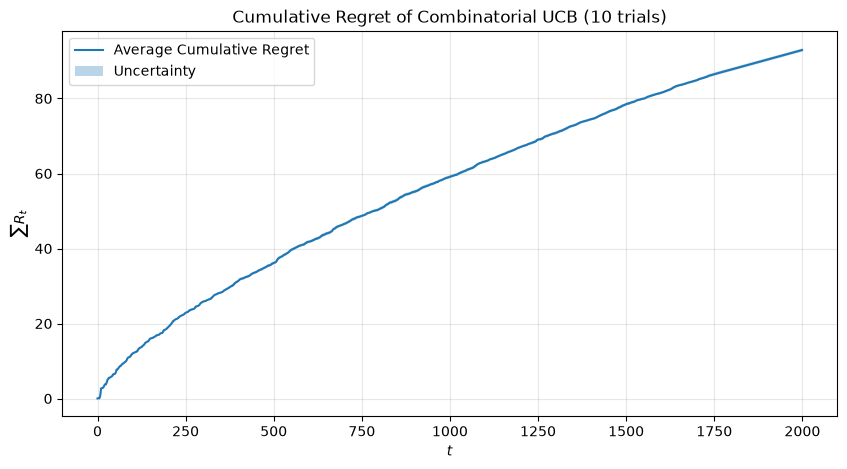

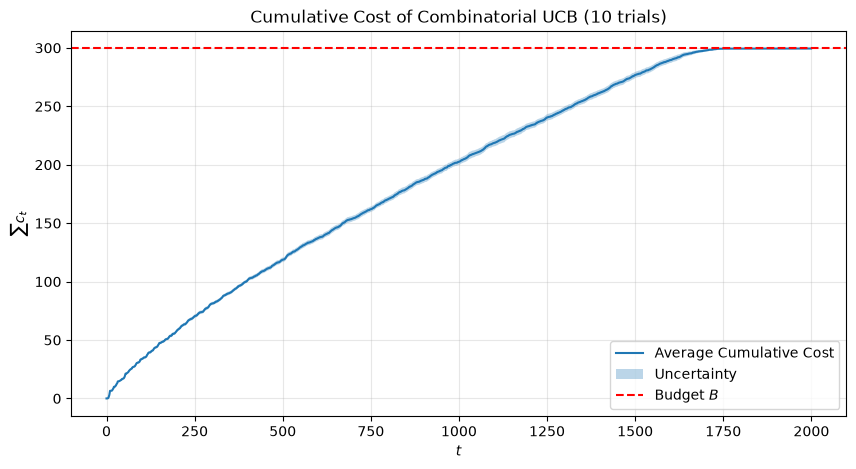

Final average regret: 92.9140000000007
Final average cost: 299.4200000000001 / Budget: 300


In [30]:
# --- Cumulative regret ---
plt.figure(figsize=(10, 5))
plt.plot(rounds, avg_regret, label="Average Cumulative Regret")
plt.fill_between(
    rounds,
    avg_regret - std_regret / np.sqrt(n_trials),
    avg_regret + std_regret / np.sqrt(n_trials),
    alpha=0.3,
    label="Uncertainty"
)
plt.xlabel("$t$")
plt.ylabel(r"$\sum R_t$")
plt.title(f"Cumulative Regret of Combinatorial UCB ({n_trials} trials)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Cumulative cost vs budget ---
plt.figure(figsize=(10, 5))
plt.plot(rounds, avg_cost, label="Average Cumulative Cost")
plt.fill_between(
    rounds,
    avg_cost - std_cost / np.sqrt(n_trials),
    avg_cost + std_cost / np.sqrt(n_trials),
    alpha=0.3,
    label="Uncertainty"
)
plt.axhline(B, color="red", linestyle="--", label="Budget $B$")
plt.xlabel("$t$")
plt.ylabel(r"$\sum c_t$")
plt.title(f"Cumulative Cost of Combinatorial UCB ({n_trials} trials)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final average regret:", avg_regret[-1])
print("Final average cost:", avg_cost[-1], "/ Budget:", B)